#Import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score






#Read Data & Explore

In [2]:
df=pd.read_csv("/content/liver_cirrhosis.csv")

In [3]:
df.columns

Index(['Patient_ID', 'N_Days_of suffering', 'Drug', 'Age_in days', 'Sex',
       'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin',
       'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides',
       'Platelets', 'Prothrombin', 'Stage_of_disease'],
      dtype='object')

In [4]:
df.head()

,Patient_ID,N_Days_of suffering,Drug,Age_in days,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage_of_disease
0,1,2221,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,2,1230,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,3,4184,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,4,2090,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,5,2105,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           25000 non-null  int64  
 1   N_Days_of suffering  25000 non-null  int64  
 2   Drug                 25000 non-null  object 
 3   Age_in days          25000 non-null  int64  
 4   Sex                  25000 non-null  object 
 5   Ascites              25000 non-null  object 
 6   Hepatomegaly         25000 non-null  object 
 7   Spiders              25000 non-null  object 
 8   Edema                25000 non-null  object 
 9   Bilirubin            25000 non-null  float64
 10  Cholesterol          25000 non-null  float64
 11  Albumin              25000 non-null  float64
 12  Copper               25000 non-null  float64
 13  Alk_Phos             25000 non-null  float64
 14  SGOT                 25000 non-null  float64
 15  Tryglicerides        25000 non-null 

#clean data


In [6]:
df.isna().sum()


,0
Patient_ID,0
N_Days_of suffering,0
Drug,0
Age_in days,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
cat_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
df= pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [9]:
df = df.drop(columns=['Patient_ID'])

In [10]:
df=df.drop(columns=['Edema_Y'])

#Feature Engineering

In [11]:
df['Age_in_years'] = df['Age_in days'] / 365.25
df = df.drop(columns=['Age_in days'])

In [12]:
df['APRI'] = (df['SGOT'] / 40) / df['Platelets'] * 100

In [13]:
df['Bilirubin_Albumin_ratio'] = df['Bilirubin'] / df['Albumin']

In [14]:
df.head()

,N_Days_of suffering,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage_of_disease,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Age_in_years,APRI,Bilirubin_Albumin_ratio
0,2221,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1,1,0,0,1,0,0,50.647502,0.514648,0.123762
1,1230,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2,1,1,1,0,1,0,54.001369,0.511364,0.127226
2,4184,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2,1,0,0,0,0,0,32.413415,1.360556,0.141243
3,2090,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2,1,0,0,0,0,0,45.084189,1.283113,0.187166
4,2105,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1,1,0,0,1,0,0,59.408624,1.796358,0.536723


In [15]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
df[num_cols].skew().sort_values(ascending=False)


,0
Cholesterol,4.109331
Alk_Phos,3.387249
Tryglicerides,3.283869
APRI,2.995804
Bilirubin_Albumin_ratio,2.655987
Bilirubin,2.572463
Copper,2.506663
Sex_M,2.421184
Edema_S,1.983553
Prothrombin,1.861805


In [16]:
skewed_cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'Tryglicerides']
for col in skewed_cols:
    df[f'log_{col}'] = np.log1p(df[col])

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Stage_of_disease'] = le.fit_transform(df['Stage_of_disease'])
print('Original classes:', le.classes_)
print('Encoded as       :', list(range(len(le.classes_))))

Original classes: [1 2 3]
Encoded as       : [0, 1, 2]


#Visualization

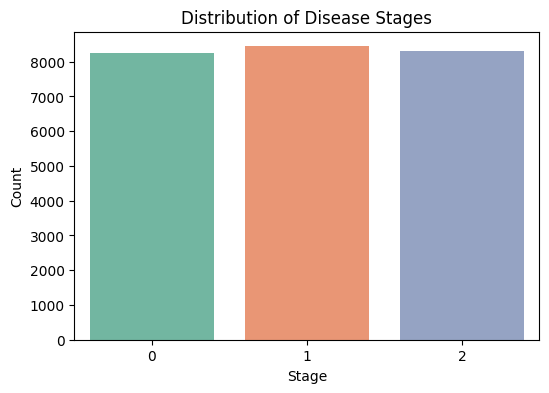

Stage_of_disease
1    33.764
2    33.176
0    33.060
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Stage_of_disease', data=df, hue='Stage_of_disease', palette='Set2', legend=False)
plt.title('Distribution of Disease Stages')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

print(df['Stage_of_disease'].value_counts(normalize=True) * 100)

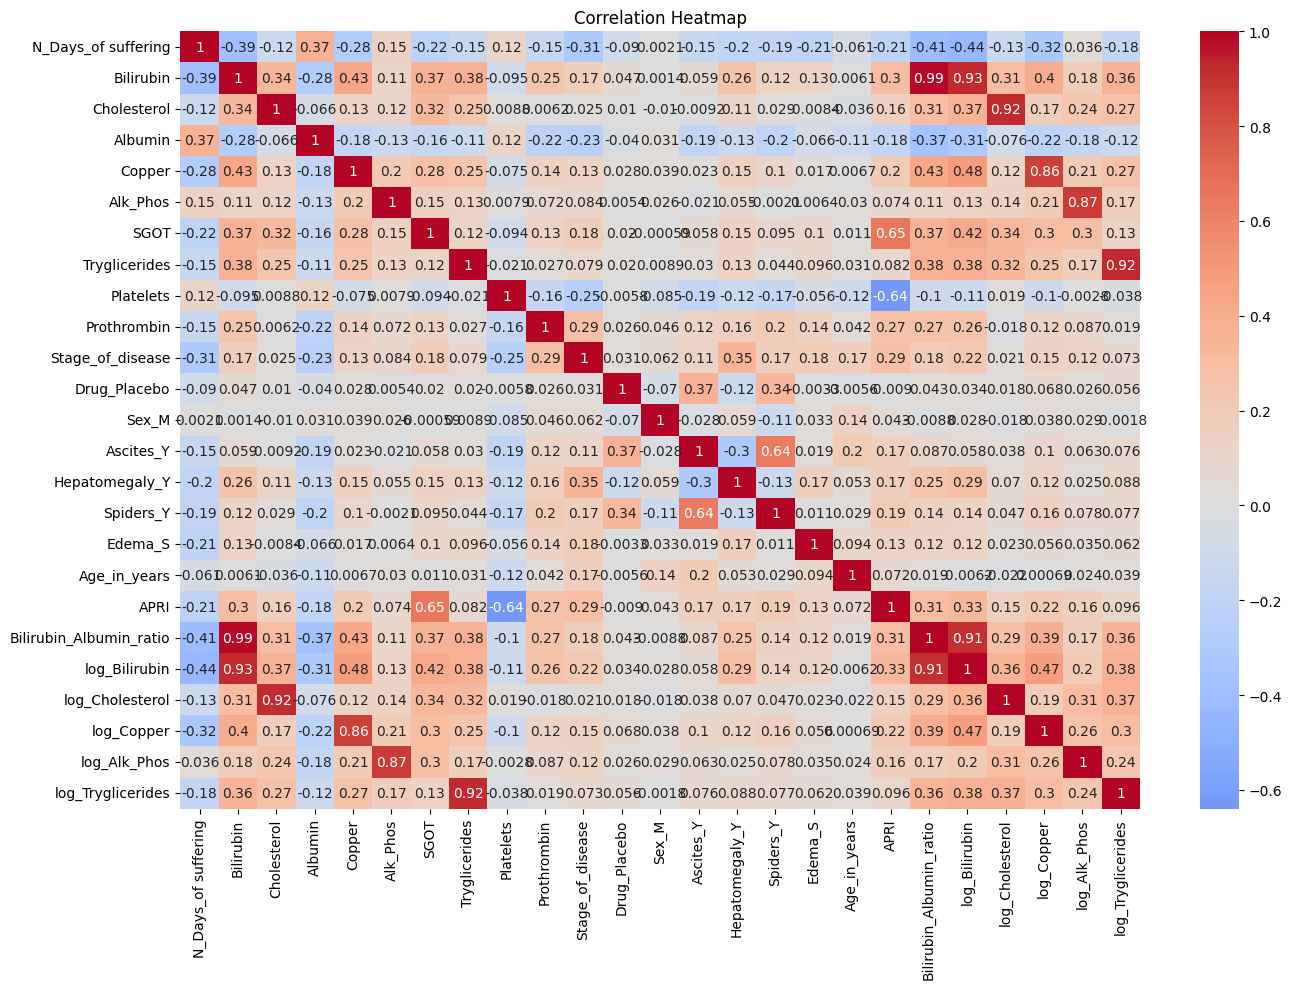

Stage_of_disease           1.000000
Hepatomegaly_Y             0.353210
APRI                       0.288478
Prothrombin                0.288107
log_Bilirubin              0.224943
Edema_S                    0.181869
Bilirubin_Albumin_ratio    0.178398
SGOT                       0.175301
Spiders_Y                  0.168049
Bilirubin                  0.168006
Age_in_years               0.165988
log_Copper                 0.145354
Copper                     0.131763
log_Alk_Phos               0.118448
Ascites_Y                  0.111012
Alk_Phos                   0.084407
Tryglicerides              0.079228
log_Tryglicerides          0.072783
Sex_M                      0.061687
Drug_Placebo               0.030862
Cholesterol                0.025415
log_Cholesterol            0.020975
Albumin                   -0.231631
Platelets                 -0.250058
N_Days_of suffering       -0.309484
Name: Stage_of_disease, dtype: float64


In [19]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# أعلى المتغيرات ارتباطًا بالـ target
print(corr['Stage_of_disease'].sort_values(ascending=False))

#Split data

In [20]:

X=df.drop("Stage_of_disease",axis=1)
y=df["Stage_of_disease"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


#models LogisticRegression

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

train_acc=accuracy_score(y_train,model_lr.predict(X_train_scaled))
print("Train Accuracy:", train_acc)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:")
print(cm_lr)

recall_score_lr = recall_score(y_test, y_pred_lr, average='weighted')
print("Recall Score:", recall_score_lr)

precision_score_lr = precision_score(y_test, y_pred_lr, average='weighted')
print("Precision Score:", precision_score_lr)

f1_score_lr = f1_score(y_test, y_pred_lr, average='weighted')
print("F1 Score:", f1_score_lr)

Train Accuracy: 0.6057
Logistic Regression Accuracy: 0.6132
Confusion Matrix:
[[ 990  433  234]
 [ 461  930  306]
 [ 208  292 1146]]
Recall Score: 0.6132
Precision Score: 0.6122438212610641
F1 Score: 0.6126596273366307


#Model DecisionTreeClassifier

In [23]:
from sklearn.tree import DecisionTreeClassifier
model_dt =DecisionTreeClassifier(max_depth=5)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

train_acc_df=accuracy_score(y_train,model_dt.predict(X_train))
print("Train Accuracy:", train_acc_df)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm_dt)

recall_score_dt = recall_score(y_test, y_pred_dt, average='weighted')
print("Recall Score:", recall_score_dt)

precision_score_dt = precision_score(y_test, y_pred_dt, average='weighted')
print("Precision Score:", precision_score_dt)


f1_score_dt = f1_score(y_test, y_pred_dt, average='weighted')
print("F1 Score:", f1_score_dt)



Train Accuracy: 0.6611
Decision Tree Accuracy: 0.6496
Confusion Matrix:
[[1196  378   83]
 [ 449 1090  158]
 [ 214  470  962]]
Recall Score: 0.6496
Precision Score: 0.6673495407993976
F1 Score: 0.6513210785183725


#Model RandomForestClassifier

In [24]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=1000, random_state=42,max_depth=12,min_samples_split=10,min_samples_leaf=4)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

train_acc_rf=accuracy_score(y_train,model_rf.predict(X_train))
print("Train Accuracy:", train_acc_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

recall_score_rf = recall_score(y_test, y_pred_rf, average='weighted')
print("Recall Score:", recall_score_rf)

precision_score_rf = precision_score(y_test, y_pred_rf, average='weighted')
print("Precision Score:", precision_score_rf)


f1_score_rf = f1_score(y_test, y_pred_rf, average='weighted')
print("F1 Score:", f1_score_rf)

Train Accuracy: 0.94265
Random Forest Accuracy: 0.9204
Confusion Matrix:
[[1478  141   38]
 [  68 1572   57]
 [  31   63 1552]]
Recall Score: 0.9204
Precision Score: 0.9212219621832921
F1 Score: 0.920466419352602


In [25]:
from sklearn.model_selection import GridSearchCV
param_grid_rf = {
    'n_estimators': [300, 400, 500],
    'max_depth': [None, 30, 40, 50],
}


rf_base = RandomForestClassifier(random_state=42)


grid_search_rf = GridSearchCV(estimator=rf_base ,param_grid=param_grid_rf ,cv=5 ,scoring='accuracy' ,n_jobs=-1)


grid_search_rf.fit(X_train, y_train)



print("best bara",grid_search_rf.best_params_)


best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)


print("Best Accuracy Random Forest:", accuracy_score(y_test, y_pred_best_rf))

f1_score_best_rf = f1_score(y_test, y_pred_best_rf, average='weighted')
print("F1 Score (Best RF):", f1_score_best_rf)

best bara {'max_depth': 30, 'n_estimators': 300}
Best Accuracy Random Forest: 0.947
F1 Score (Best RF): 0.9469919540943978


#Feature importance rf

Prothrombin                0.114273
Platelets                  0.082601
N_Days_of suffering        0.082334
Albumin                    0.077898
Bilirubin_Albumin_ratio    0.067432
Age_in_years               0.065804
APRI                       0.063640
log_Bilirubin              0.042084
Hepatomegaly_Y             0.041663
Bilirubin                  0.040142
SGOT                       0.033436
Copper                     0.030699
Alk_Phos                   0.030655
log_Alk_Phos               0.030579
log_Copper                 0.030530
log_Cholesterol            0.029044
Cholesterol                0.029011
Tryglicerides              0.028177
log_Tryglicerides          0.027082
Edema_S                    0.014356
Spiders_Y                  0.011737
Ascites_Y                  0.011087
Drug_Placebo               0.009973
Sex_M                      0.005766
dtype: float64


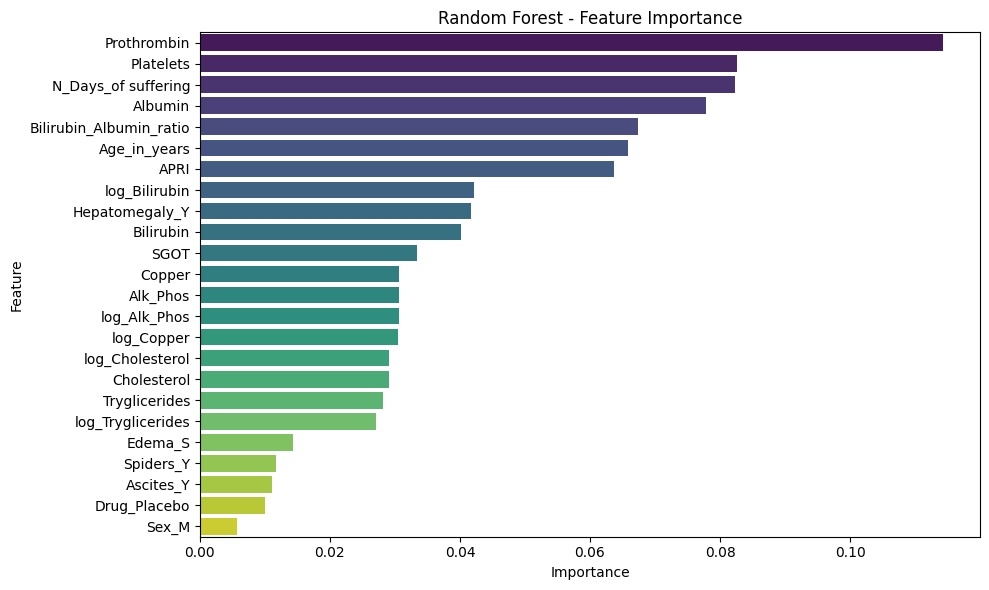

In [26]:
importances_rf = pd.Series(best_rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_rf)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_rf.values, y=importances_rf.index, hue=importances_rf.index, palette='viridis', legend=False)
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Model LGM

In [27]:

from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(X_train, y_train)

y_pred_lgbm = model_lgbm.predict(X_test)

train_acc_lgbm=accuracy_score(y_train,model_lgbm.predict(X_train))
print("Train Accuracy:", train_acc_lgbm)

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
print("LightGBM Accuracy:", accuracy_lgbm)

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
print("Confusion Matrix:")
print(cm_lgbm)

recall_score_lgbm = recall_score(y_test, y_pred_lgbm, average='weighted')
precision_score_lgbm = precision_score(y_test, y_pred_lgbm, average='weighted')
print("Recall Score:", recall_score_lgbm)
print("Precision Score:", precision_score_lgbm)

f1_score_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')
print("F1 Score:", f1_score_lgbm)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3331
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 24
[LightGBM] [Info] Start training from score -1.107451
[LightGBM] [Info] Start training from score -1.087079
[LightGBM] [Info] Start training from score -1.101416
Train Accuracy: 0.97585
LightGBM Accuracy: 0.9602
Confusion Matrix:
[[1563   75   19]
 [  26 1643   28]
 [  19   32 1595]]
Recall Score: 0.9602
Precision Score: 0.9605509616505952
F1 Score: 0.9602270200200071


In [28]:


param_grid_lgbm = {
    'n_estimators': [300, 400, 500],
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.2, 0.3, 0.4],
}

lgbm_base = LGBMClassifier(random_state=42)

grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_lgbm.fit(X_train, y_train)

print("Best Parameters:", grid_search_lgbm.best_params_)

best_lgbm_model = grid_search_lgbm.best_estimator_
y_pred_best_lgbm = best_lgbm_model.predict(X_test)

print("Best Accuracy LightGBM:", accuracy_score(y_test, y_pred_best_lgbm))

f1_score_best_lgbm = f1_score(y_test, y_pred_best_lgbm, average='weighted')
print("F1 Score (Best LGBM):", f1_score_best_lgbm)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002553 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3331
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 24
[LightGBM] [Info] Start training from score -1.107451
[LightGBM] [Info] Start training from score -1.087079
[LightGBM] [Info] Start training from score -1.101416
Best Parameters: {'learning_rate': 0.2, 'n_estimators': 300, 'num_leaves': 20}
Best Accuracy LightGBM: 0.9634
F1 Score (Best LGBM): 0.9634165919086302


#Feature importance  LGM

Platelets                  1350
Albumin                    1258
Prothrombin                1179
Age_in_years               1027
N_Days_of suffering         827
Bilirubin_Albumin_ratio     623
Copper                      394
Cholesterol                 333
Alk_Phos                    313
SGOT                        312
APRI                        270
Bilirubin                   262
Tryglicerides               234
Hepatomegaly_Y              170
Edema_S                     130
Drug_Placebo                104
Ascites_Y                    90
Spiders_Y                    74
Sex_M                        50
log_Bilirubin                 0
log_Cholesterol               0
log_Copper                    0
log_Alk_Phos                  0
log_Tryglicerides             0
dtype: int32


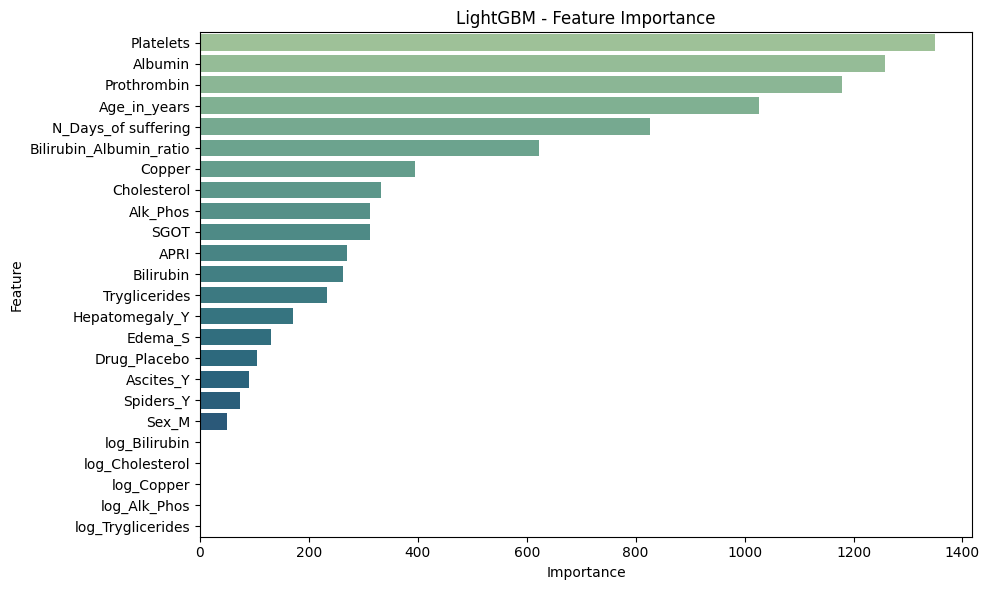

In [29]:
importances_lgbm = pd.Series(model_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_lgbm)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_lgbm.values, y=importances_lgbm.index, hue=importances_lgbm.index, palette='crest', legend=False)
plt.title("LightGBM - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Model CSV

In [30]:
from sklearn.svm import SVC



model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)

train_acc_svm=accuracy_score(y_train,model_svm.predict(X_train_scaled))
print("Train Accuracy:", train_acc_svm)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))

f1_score_svm = f1_score(y_test, y_pred_svm, average='weighted')
print("F1 Score:", f1_score_svm)

Train Accuracy: 0.8418
SVM Accuracy: 0.826
Confusion Matrix:
[[1352  236   69]
 [ 184 1389  124]
 [ 101  156 1389]]
Recall: 0.826
Precision: 0.8274397344405517
F1 Score: 0.826440206408921


#Model KNN

In [31]:
from sklearn.neighbors import KNeighborsClassifier



model_knn = KNeighborsClassifier(n_neighbors=7)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

train_acc_knn=accuracy_score(y_train,model_knn.predict(X_train_scaled))
print("Train Accuracy:", train_acc_knn)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))

f1_score_knn = f1_score(y_test, y_pred_knn, average='weighted')
print("F1 Score:", f1_score_knn)

Train Accuracy: 0.9078
KNN Accuracy: 0.8748
Confusion Matrix:
[[1428  165   64]
 [ 126 1486   85]
 [  66  120 1460]]
Recall: 0.8748
Precision: 0.875619397859976
F1 Score: 0.8750022200954749


#Model xgboost

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(random_state=42,max_depth=3,n_estimators=150)

xgb_model.fit(X_train, y_train)

train_acc_xgb=accuracy_score(y_train,xgb_model.predict(X_train))
print("Train Accuracy:", train_acc_xgb)

y_pred_xgb = xgb_model.predict(X_test)
print("accuracy XGBoost:", accuracy_score(y_test, y_pred_xgb))

cm_xg=confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:")
print(cm_xg)

recall_score_xg = recall_score(y_test, y_pred_xgb, average='weighted')
print("Recall Score:", recall_score_xg)

precision_score_xg = precision_score(y_test, y_pred_xgb, average='weighted')

print("Precision Score:", precision_score_xg)

f1_score_xg = f1_score(y_test, y_pred_xgb, average='weighted')
print("F1 Score:", f1_score_xg)

Train Accuracy: 0.9508
accuracy XGBoost: 0.9418
Confusion Matrix:
[[1545   90   22]
 [  52 1611   34]
 [  28   65 1553]]
Recall Score: 0.9418
Precision Score: 0.9424385835808693
F1 Score: 0.9419236174614584


In [33]:
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [1, 2, 3],
}

xgb_base = XGBClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_xgb_model = grid_search.best_estimator_
y_pred_best = best_xgb_model.predict(X_test)

print("Best Accuracy XGBoost ", accuracy_score(y_test, y_pred_best))

f1_score_best_xgb = f1_score(y_test, y_pred_best, average='weighted')
print("F1 Score (Best XGBoost):", f1_score_best_xgb)

Best Parameters: {'max_depth': 3, 'n_estimators': 150}
Best Accuracy XGBoost  0.9418
F1 Score (Best XGBoost): 0.9419236174614584


#Feature importance xg


Hepatomegaly_Y             0.174627
Prothrombin                0.066731
Edema_S                    0.061406
Ascites_Y                  0.059587
Drug_Placebo               0.058822
Alk_Phos                   0.056585
Bilirubin_Albumin_ratio    0.052552
N_Days_of suffering        0.051961
Platelets                  0.048385
Albumin                    0.048043
SGOT                       0.044679
Tryglicerides              0.042000
Copper                     0.040303
Cholesterol                0.038728
Age_in_years               0.038414
Bilirubin                  0.035890
APRI                       0.034866
Sex_M                      0.026078
Spiders_Y                  0.020342
log_Bilirubin              0.000000
log_Cholesterol            0.000000
log_Copper                 0.000000
log_Alk_Phos               0.000000
log_Tryglicerides          0.000000
dtype: float32


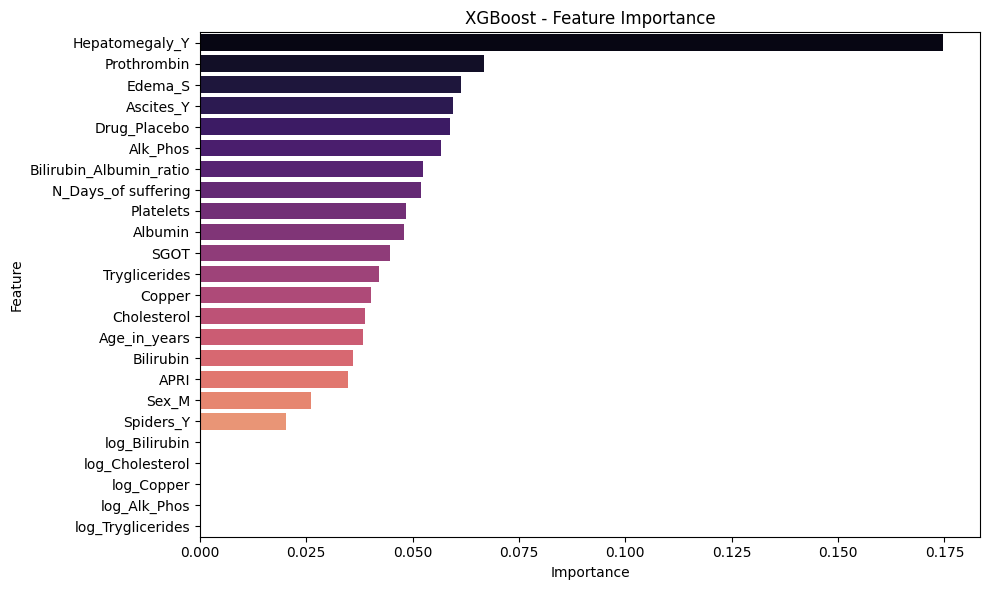

In [34]:
importances_xgb = pd.Series(best_xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_xgb)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_xgb.values, y=importances_xgb.index, hue=importances_xgb.index, palette='magma', legend=False)
plt.title("XGBoost - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#stacking

In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=30, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=7, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=300, num_leaves=20, learning_rate=0.2, random_state=42)),
]

meta_model = LogisticRegression(max_iter=1000)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

train_acc_stack = accuracy_score(y_train, stacking_model.predict(X_train))
print("Train Accuracy:", train_acc_stack)

y_pred_stack = stacking_model.predict(X_test)
accuracy_stack = accuracy_score(y_test, y_pred_stack)
print("Stacking Accuracy:", accuracy_stack)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_stack, average='weighted'))

f1_score_stack = f1_score(y_test, y_pred_stack, average='weighted')
print("F1 Score:", f1_score_stack)

Train Accuracy: 0.994
Stacking Accuracy: 0.967
Confusion Matrix:
[[1587   53   17]
 [  28 1646   23]
 [  20   24 1602]]
Recall: 0.967
Precision: 0.9670837226336749
F1 Score: 0.9670082331262373


#Compare

                   Model  Accuracy  F1 Score
0               Stacking    0.9670  0.967008
1       LightGBM (tuned)    0.9634  0.963417
2  Random Forest (tuned)    0.9470  0.946992
3        XGBoost (tuned)    0.9418  0.941924
4                    KNN    0.8748  0.875002
5                    SVM    0.8260  0.826440
6          Decision Tree    0.6496  0.651321
7    Logistic Regression    0.6132  0.612660


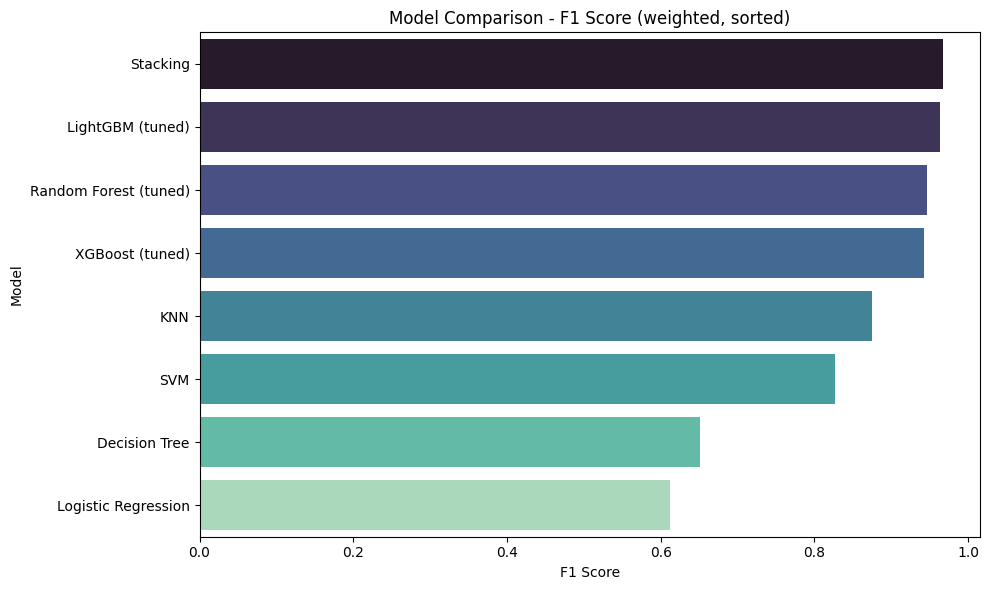

In [41]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest (tuned)', 'LightGBM (tuned)',
              'SVM', 'KNN', 'XGBoost (tuned)', 'Stacking'],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_lgbm),
        accuracy_svm,
        accuracy_knn,
        accuracy_score(y_test, y_pred_best),
        accuracy_stack
    ],
    'F1 Score': [
        f1_score_lr, f1_score_dt, f1_score_best_rf, f1_score_best_lgbm,
        f1_score_svm, f1_score_knn, f1_score_best_xgb, f1_score_stack
    ]
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print(results)

plt.figure(figsize=(10,6))
sns.barplot(data=results, x='F1 Score', y='Model', hue='Model', palette='mako', legend=False)
plt.title('Model Comparison - F1 Score (weighted, sorted)')
plt.xlabel('F1 Score')
plt.tight_layout()
plt.show()

#Save Best Model

In [42]:
import joblib

joblib.dump(stacking_model, 'best_stacking_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')


['label_encoder.pkl']